In [1]:
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

In [2]:
import pickle

with open('data/processed/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)
    
X_train_proc = data['X_train_proc']
X_val_proc = data['X_val_proc']
X_test_proc = data['X_test_proc']
y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']
train_df = data['train_df']
numeric_features = data['numeric_features']
test_df = ['test_df']
preprocessor = ['preprocessor']

#### Decision tree over max_depth

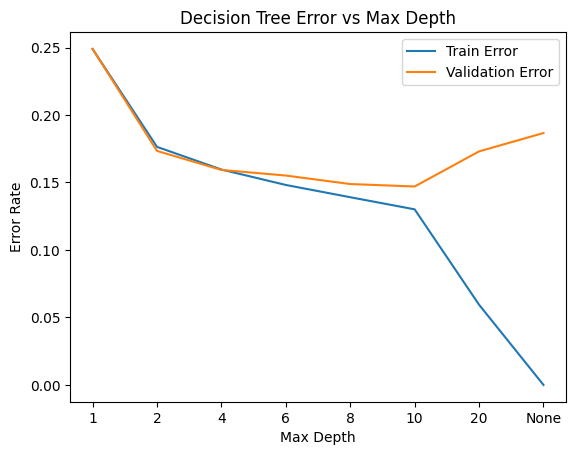

In [3]:
depths = [1, 2, 4, 6, 8, 10, 20, None]
train_err_dt, val_err_dt = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train_proc, y_train)
    train_err_dt.append(1 - clf.score(X_train_proc, y_train))
    val_err_dt.append(1 - clf.score(X_val_proc, y_val))

plt.figure()
plt.plot([str(d) for d in depths], train_err_dt, label="Train Error")
plt.plot([str(d) for d in depths], val_err_dt, label="Validation Error")
plt.title("Decision Tree Error vs Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Error Rate")
plt.legend()
plt.show()

#### Random forest over n_estimators

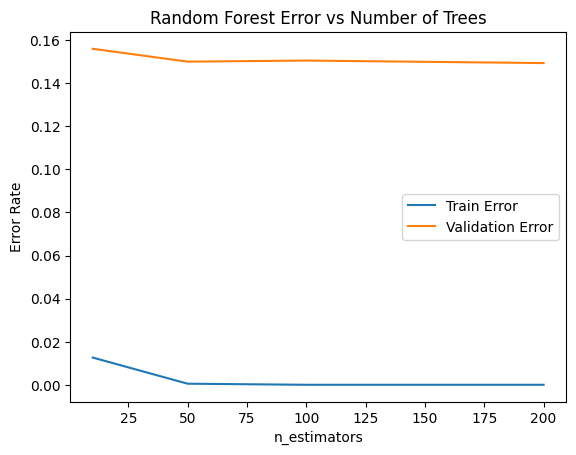

In [4]:
estimators = [10, 50, 100, 200]
train_err_rf, val_err_rf = [], []

for n in estimators:
    clf = RandomForestClassifier(n_estimators=n, max_depth=None, random_state=42, n_jobs=-1)
    clf.fit(X_train_proc, y_train)
    train_err_rf.append(1 - clf.score(X_train_proc, y_train))
    val_err_rf.append(1 - clf.score(X_val_proc, y_val))

plt.figure()
plt.plot(estimators, train_err_rf, label="Train Error")
plt.plot(estimators, val_err_rf, label="Validation Error")
plt.title("Random Forest Error vs Number of Trees")
plt.xlabel("n_estimators")
plt.ylabel("Error Rate")
plt.legend()
plt.show()

#### AdaBoost n_estimators

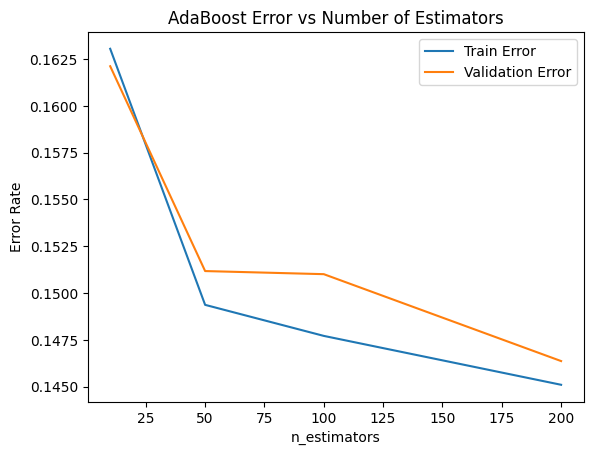

In [5]:
train_err_ab, val_err_ab = [], []

for n in estimators:
    clf = AdaBoostClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train_proc, y_train)
    train_err_ab.append(1 - clf.score(X_train_proc, y_train))
    val_err_ab.append(1 - clf.score(X_val_proc, y_val))

plt.figure()
plt.plot(estimators, train_err_ab, label="Train Error")
plt.plot(estimators, val_err_ab, label="Validation Error")
plt.title("AdaBoost Error vs Number of Estimators")
plt.xlabel("n_estimators")
plt.ylabel("Error Rate")
plt.legend()
plt.show()

#### Gradient boosting over learning_rate

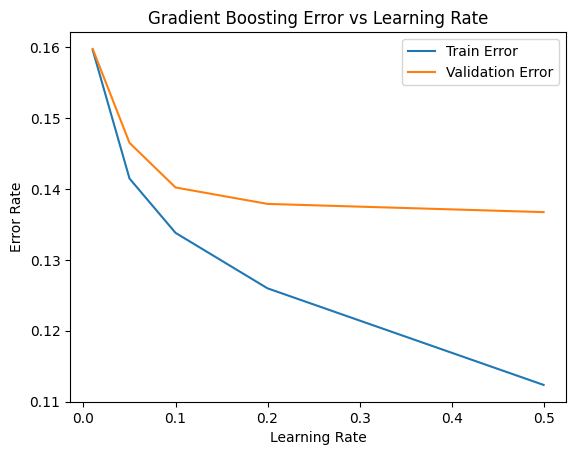

In [6]:
lrs = [0.01, 0.05, 0.1, 0.2, 0.5]
train_err_gb, val_err_gb = [], []

for lr in lrs:
    clf = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, random_state=42)
    clf.fit(X_train_proc, y_train)
    train_err_gb.append(1 - clf.score(X_train_proc, y_train))
    val_err_gb.append(1 - clf.score(X_val_proc, y_val))

plt.figure()
plt.plot(lrs, train_err_gb, label="Train Error")
plt.plot(lrs, val_err_gb, label="Validation Error")
plt.title("Gradient Boosting Error vs Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("Error Rate")
plt.legend()
plt.show()

#### Random Search

In [7]:
results = {}
models = {
    "Decision Tree": (DecisionTreeClassifier(random_state=42), {
        "max_depth": [None, 5, 10, 20, 30]
    }),
    "Random Forest": (RandomForestClassifier(random_state=42, n_jobs=-1), {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "max_features": ["sqrt", "log2"]
    }),
    "AdaBoost": (AdaBoostClassifier(random_state=42), {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.1, 0.5, 1.0]
    }),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42), {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1, 0.2]
    })
}

for name, (model, param_dist) in models.items():
    start = time.time()
    search = RandomizedSearchCV(model, param_dist, n_iter=10, cv=3, n_jobs=-1, random_state=42)
    search.fit(X_train_proc, y_train)
    duration = time.time() - start
    best = search.best_estimator_
    test_acc = best.score(X_test_proc, y_test)
    results[name] = {
        "best_params": search.best_params_,
        "test_accuracy": test_acc,
        "tuning_time_sec": duration
    }

/opt/homebrew/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


#### Results

In [8]:
results = {}
models = {
    "Decision Tree": (DecisionTreeClassifier(random_state=42), {
        "max_depth": [None, 5, 10, 20, 30]
    }),
    "Random Forest": (RandomForestClassifier(random_state=42, n_jobs=-1), {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "max_features": ["sqrt", "log2"]
    }),
    "AdaBoost": (AdaBoostClassifier(random_state=42), {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.1, 0.5, 1.0]
    }),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42), {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1, 0.2]
    })
}

for name, (model, param_dist) in models.items():
    start = time.time()
    search = RandomizedSearchCV(model, param_dist, n_iter=10, cv=3, n_jobs=-1, random_state=42)
    search.fit(X_train_proc, y_train)
    duration = time.time() - start
    best = search.best_estimator_
    test_acc = best.score(X_test_proc, y_test)
    results[name] = {
        "best_params": search.best_params_,
        "test_accuracy": test_acc,
        "tuning_time_sec": duration
    }

/opt/homebrew/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


#### Tree visualization and feature importance

In [12]:
X = train_df.drop('income', axis=1)
y = train_df['income']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_test = test_df.drop(columns = ['income'], axis=1)
y_test = test_df['income']

numeric_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_features = [col for col in X.columns if col not in numeric_features]

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

AttributeError: 'list' object has no attribute 'drop'

In [ ]:
best_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    {"max_depth": [None, 5, 10, 20, 30]}, n_iter=5, cv=3, random_state=42
).fit(X_train_proc, y_train).best_estimator_

plt.figure(figsize=(25, 10))
plot_tree(best_dt, max_depth=2, filled=True, feature_names=(
    numeric_features + list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features))
))
plt.title("Top Levels of Best Decision Tree")
plt.show()

importances = {}
for name, info in results.items():
    model = models[name][0].set_params(**info["best_params"]).fit(X_train_proc, y_train)
    importances[name] = model.feature_importances_

AttributeError: 'list' object has no attribute 'named_transformers_'

In [ ]:
import pickle
import os

os.makedirs('data/processed', exist_ok=True)

data_to_save = {
    # Data
    'X_train_proc': X_train_proc,
    'X_val_proc': X_val_proc,
    'X_test_proc': X_test_proc,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    
    # Tree experiment results
    'tree_depths': depths,
    'train_err_dt': train_err_dt,
    'val_err_dt': val_err_dt,
    
    # Random Forest results
    'train_err_rf': train_err_rf,
    'val_err_rf': val_err_rf,
    
    # Best models from tuning
    'tree_models': models,  
    'tree_results': results
}

with open('data/processed/tree_models_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

print("Saved tree-based model results to data/processed/tree_models_data.pkl")